# ScopeSim Sources

## ScopeSim `Source` and `SourceField` Overview

### What is a `Source`?

`Source` is the top-level target container passed into `OpticalTrain.observe()`.
It combines:

- **Spatial information**: where light is on sky (`source.fields`)
- **Spectral information**: what spectrum each component has (`source.spectra`)
- **Metadata**: extra context (`source.meta`)

A single `Source` can hold multiple components (e.g., stars + diffuse background + cube).

---

### What is a `SourceField`?

`Source.fields` is a list that stores `SourceField` objects representing one spatial/spectral component.

Available field types (subclasses of `SourceField`):

1. **`TableSourceField`**
   - Stores an `astropy.table.Table` with point-source rows.
   - Typical columns: `x`, `y`, `ref`, `weight`.
   - `ref` maps each row to an entry in `source.spectra`.

2. **`ImageSourceField`**
   - Stores a 2D `fits.ImageHDU` (surface-brightness map).
   - Uses WCS in header for sky-to-pixel mapping.
   - Usually linked to one spectrum via header metadata (e.g., `SPEC_REF`).

3. **`CubeSourceField`**
   - Stores a 3D cube (`fits.ImageHDU`) with spatial + wavelength axes.
   - Contains its own spectral axis (not just one average spectrum).

---

In [1]:
import numpy as np
import astropy.units as u
from astropy.table import Table
from astropy.io import fits

import scopesim_templates as sim_tp
from scopesim.source.source import Source
import scopesim.source.source_templates  as source_templates

from zs_scopesim_tools.plots import PlotScene
plotter = PlotScene()

## How to create `Source` objects

### A) From a point-source table + spectra

In [2]:
# Two point sources at (0,0) & (1.2,-0.5), both their spectra at index 0 in spectra list
tbl = Table(
    data=[[0.0, 1.2], [0.0, -0.5], [0, 0], [1.0, 0.7]],
    names=["x", "y", "ref", "weight"],
)
tbl["x"].unit = u.arcsec
tbl["y"].unit = u.arcsec

ps = Source(table=tbl, spectra=[source_templates.vega_spectrum(10)], name="Stars")
ps.fields

[TableSourceField(field=<Table length=2>
    x       y     ref   weight
  arcsec  arcsec              
 float64 float64 int64 float64
 ------- ------- ----- -------
     0.0     0.0     0     1.0
     1.2    -0.5     0     0.7, spectra={0: <synphot.spectrum.SourceSpectrum object at 0x10fa84260>})]

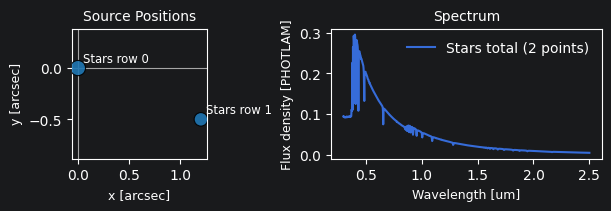

In [3]:
fig, axs = plotter.from_source(ps)

### B) From an image HDU + spectrum


[ImageSourceField(field=<astropy.io.fits.hdu.image.ImageHDU object at 0x10fee46e0>, wcs=WCS Keywords

Number of WCS axes: 2
CTYPE : '' ''
CUNIT : 'deg' 'deg'
CRVAL : 0.0 0.0
CRPIX : 0.0 0.0
PC1_1 PC1_2  : 1.0 0.0
PC2_1 PC2_2  : 0.0 1.0
CDELT : 0.000277777777777777 0.000277777777777777
NAXIS : 60  60, spectra={0: <synphot.spectrum.SourceSpectrum object at 0x10fdab740>})]


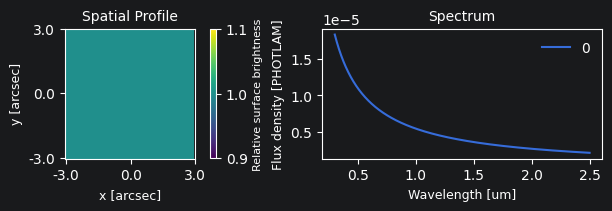

In [4]:
img = np.ones((60, 60), dtype=float)
hdr = fits.Header(cards={'CUNIT1':'arcsec', 'CUNIT2':'arcsec', 'CDELT1':1, 'CDELT2':1}) # need to include this minimal header
hdu = fits.ImageHDU(data=img, header=hdr)

im = Source(image_hdu=hdu, spectra=[source_templates.ab_spectrum(mag=20)]) # ab_spectrum creates a spectrum with constant flux in magnitude space of given mag (which does not mean constant in erg/s/cm2/Angstrom)
print(im.fields)
fig, axs = plotter.from_source(im, pixel_scale=0.1)  # 0.1 arcsec/pixel for plotting

NOTE: Can also use `src.source_templates.uniform_source()` to create the above source in one step as shown below. The default spatial sampling is 1 arcsec/pixel.

[ImageSourceField(field=<astropy.io.fits.hdu.image.ImageHDU object at 0x10fed5610>, wcs=WCS Keywords

Number of WCS axes: 2
CTYPE : 'RA---TAN' 'DEC--TAN'
CUNIT : 'deg' 'deg'
CRVAL : 0.0 0.0
CRPIX : 32.5 32.5
PC1_1 PC1_2  : 1.0 0.0
PC2_1 PC2_2  : 0.0 1.0
CDELT : -0.00027777777777778 0.00027777777777778
NAXIS : 64  64, spectra={0: <synphot.spectrum.SourceSpectrum object at 0x10dec2060>})]


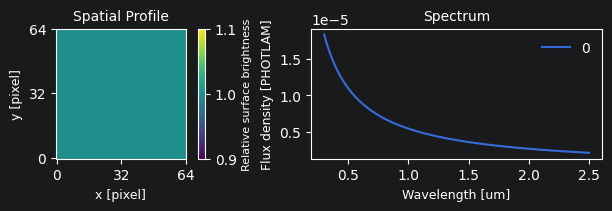

In [5]:
im2 = source_templates.uniform_source(source_templates.ab_spectrum(mag=20), extent=64)
print(im2.fields)
fig, axs = plotter.from_source(im2)

To create a uniform source use `ConstFlux1D` with the appropriate amplitude. Default amplitude unit is assumed to be
 PHOTLAM (photon/s/cm^2/Angstrom) if not supplied, but if another unit is supplied it will be converted to PHOTLAM.
 Constant flux in another unit may not be constant in PHOTLAM, so be careful in usage.

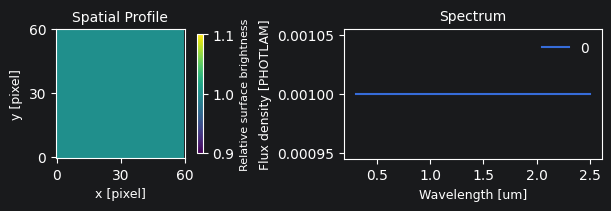

In [6]:
model = source_templates.ConstFlux1D(amplitude=0.001) # synphot model, default unit is photon/s/cm^2/Angstrom
waves = np.geomspace(100, 300000, 50000)
spectrum = source_templates.SourceSpectrum(source_templates.Empirical1D, points=waves, lookup_table=model(waves))
im3 = source_templates.uniform_source(spectrum, extent=60)
fig, axs = plotter.from_source(im3)

### C) From helper templates (quick start) available in `scopesim_templates` package

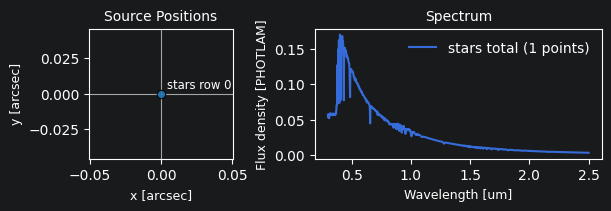

In [7]:
# star
star = sim_tp.star(filter_name='V', amplitude=10*u.ABmag) # spectra taken from 'spextra' package
_, _ = plotter.from_source(star)

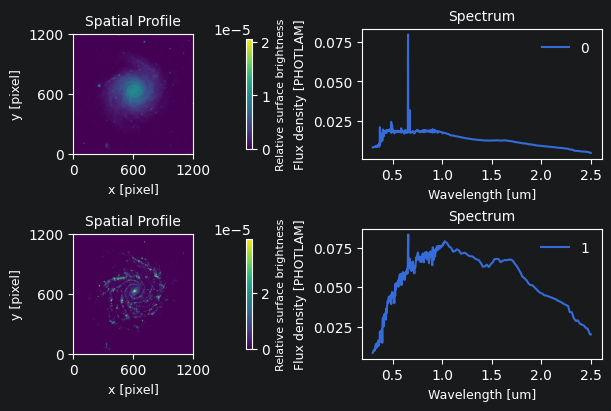

In [8]:
# Galaxy, loaded from saved fits template of NGC1232L
gal = sim_tp.extragalactic.galaxies.spiral_two_component(extent=200*u.arcsec, fluxes=(15, 15)*u.mag)
_ = plotter.from_source(gal)

Other available galaxy models include `galaxy`, `galaxy3d`, and `elliptical`. See `scopesim_templates.extragalactic.galaxies` for details.

## Some realistic examples of sources

### A uniform source to simulate dome flats

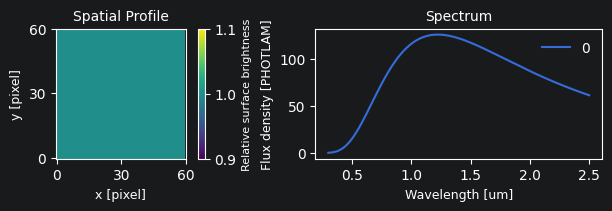

In [9]:
# Let's say we want a high-power halogen bulb emitting a 3000 K blackbody spectrum, uniformly illuminating a 1 arcmin x 1 arcmin area on the sky. We can create this source as follows:
domeflat = sim_tp.calibration.flat_field(temperature=3000*u.K, amplitude=4*u.ABmag, filter_curve='V', extend=60)
_ = plotter.from_source(domeflat)

### Arc lamps for wavelength calibration

`lamp_flat()` is a provided wrapper function that creates a uniform source with a line spectrum from given line list(s).
Look at its implementation in `zs_scopesim_tools.sources` for details. The default lines are that of ThAr, Ne and Ar lamps.

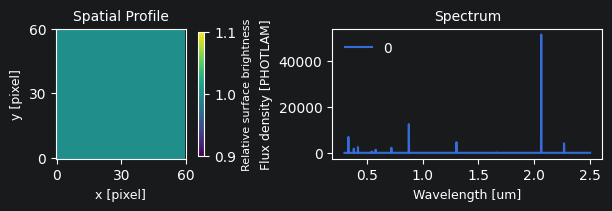

In [10]:
from zs_scopesim_tools.sources import lamp_flat
lamp = lamp_flat()
_ = plotter.from_source(lamp)

### Extragalactic transient: Supernova

Template spectra can be pulled from A-star Vienna's spextra package library:
https://scopesim.univie.ac.at/spextra/database/libraries/
``` python
from spextra import Spextrum
sed = Spextrum('brown/NGC3870')

sed = Spextrum('sne/sn1a').redshift(0.02) # redshift it to match the host galaxy
spec = sed.scale_to_magnitude(14*u.ABmag, 'g')
```

Or you can use your own (wave, flux) Quantity arrays to create a `SourceSpectrum` object
using `zs_scopesim_tools.sources.empirical_spectrum()`.

NOTE: Make sure your spectrum has appropriate resolution and wavelength coverage for your simulation.

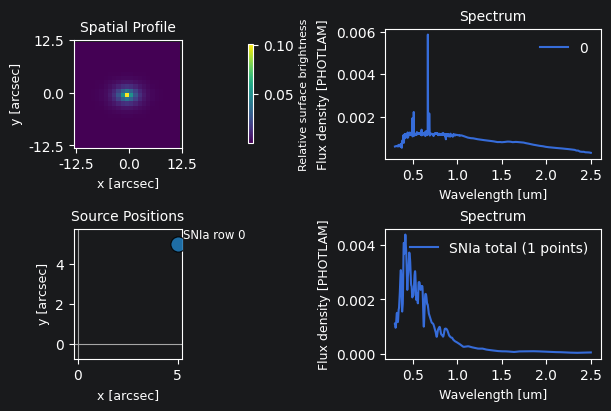

In [13]:
# base galaxy centered at 0, 0 arcsec
gal = sim_tp.galaxy(sed='brown/NGC3870', z=0.02, amplitude=15, filter_curve='g', pixel_scale=1, r_eff=2.5, n=1., ellip=0.3, theta=0, extend=5)

from zs_scopesim_tools.sources import transient
sn = transient(x=5, y=5, spextrum_template='sne/sn1a', scale_to_redshift=0.02, scale_to_mag=14*u.ABmag, filter_curve='g',
               name='SNIa')

# add sn at 5",5" offset from center
gal.append(sn)

_ = plotter.from_source(gal, pixel_scale=1.0)

astar.scopesim.optics.image_plane - WARNING: No BUNIT found in added HDU.
py.warnings - WARNING: /Users/yashvi/Desktop/ZShooter/ScopeSim/scopesim/source/source.py:501: DeprecationWarning: Adding a table directly to the ImagePlane is deprecated since v0.10.0. Passing a table to ImagePlane.add() will raise an error from version 0.12 onwards. Use FOV to add tables and image HDUs together before.
  im_plane.add(hdu_or_table, sub_pixel=sub_pixel,



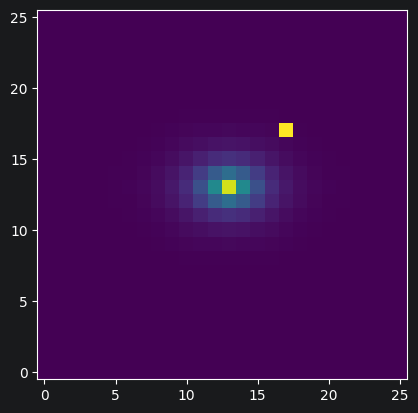

In [12]:
im = gal.image(wave_min=0.3, wave_max=2.5, pixel_scale=1*u.arcsec) # returns an ImagePlane
import matplotlib.pyplot as plt
plt.imshow(im.data, origin='lower', vmax=20000)